In [42]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from prophet import Prophet
from xgboost import XGBRegressor
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error as mae

# 1 Problem Statement:
Energy Consumption Time Series Forecasting

# 1 Objective:
Forecast short-term household energy usage using historical time-based patterns.

# 2.Dataset Description and Loading

In [4]:
#Read the file without parsing dates in the function
df = pd.read_csv('household_power_consumption.txt', sep=';', 
                 low_memory=False, na_values=['?'])

In [5]:
#Combine Date and Time columns into a single string column
df['datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], dayfirst=True)

# 3 Data cleaning and preprocessing

In [27]:
# Count detect missing values
df.isnull().sum()

Global_active_power      0
Global_reactive_power    0
Voltage                  0
Global_intensity         0
Sub_metering_1           0
Sub_metering_2           0
Sub_metering_3           0
dtype: int64

In [33]:
df = df.drop_duplicates()

In [31]:
#counting duplicates
duplicate_count = df.duplicated().sum()
print(f"Total number of duplicate rows: {duplicate_count}")

Total number of duplicate rows: 0


# Preprocessing

In [39]:
# Convert all numeric columns to float (in case they loaded as strings)
cols = ['Global_active_power', 'Global_reactive_power', 'Voltage', 
        'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']
for col in cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [6]:
#Set the new column as the index and drop the old Date/Time columns
df = df.set_index('datetime').drop(['Date', 'Time'], axis=1)

In [26]:
df = df.interpolate(method='linear')

In [7]:
# Resample to hourly mean and handle missing values via interpolation
df['Global_active_power'] = pd.to_numeric(df['Global_active_power'], errors='coerce')
df_hourly = df['Global_active_power'].resample('h').mean().interpolate()

# Engineer time-based features (e.g., hour of day, weekday/weekend)

In [8]:
def create_features(df):
    df = df.to_frame()
    df['hour'] = df.index.hour
    df['dayofweek'] = df.index.dayofweek
    df['month'] = df.index.month
    df['is_weekend'] = df.index.dayofweek.isin([5, 6]).astype(int)
    return df

df_features = create_features(df_hourly)

# 4 Exploratory Data Analysis (EDA)

In [46]:
df.describe()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
count,1.932677e+06,1.932677e+06,1.932677e+06,1.932677e+06,1.932677e+06,1.932677e+06,1.932677e+06
mean,1.147301e+00,1.315392e-01,2.407498e+02,4.865538e+00,1.190950e+00,1.382435e+00,6.781310e+00
std,1.064612e+00,1.118699e-01,3.269643e+00,4.471944e+00,6.328933e+00,5.985023e+00,8.517785e+00
min,7.600000e-02,0.000000e+00,2.232000e+02,2.000000e-01,0.000000e+00,0.000000e+00,0.000000e+00
25%,3.280000e-01,5.800000e-02,2.388700e+02,1.400000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,7.520000e-01,1.060000e-01,2.409100e+02,3.200000e+00,0.000000e+00,0.000000e+00,1.000000e+00
75%,1.576000e+00,2.000000e-01,2.428100e+02,6.600000e+00,0.000000e+00,1.000000e+00,1.800000e+01
max,1.112200e+01,1.390000e+00,2.541500e+02,4.840000e+01,8.800000e+01,8.000000e+01,3.100000e+01


# Visualizations (charts, plots, graphs)

# Time Series Visualization

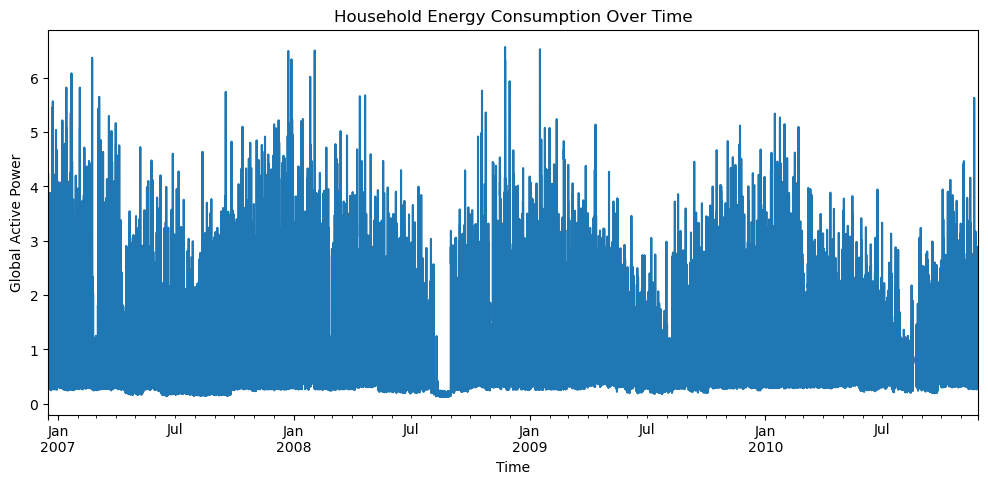

In [35]:
#Plot energy consumption over time.
df_hourly.plot(figsize=(12,5))
plt.title("Household Energy Consumption Over Time")
plt.xlabel("Time")
plt.ylabel("Global Active Power")
plt.show()

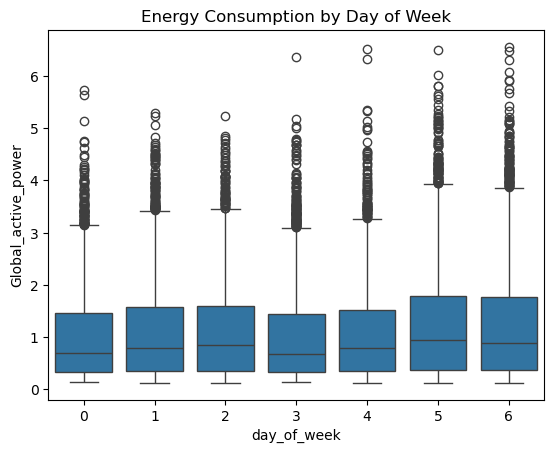

In [49]:
#This shows how energy usage values are distributed.
df_features['day_of_week'] = df_features.index.dayofweek
sns.boxplot(x='day_of_week', y='Global_active_power', data=df_features)
plt.title("Energy Consumption by Day of Week")
plt.show()

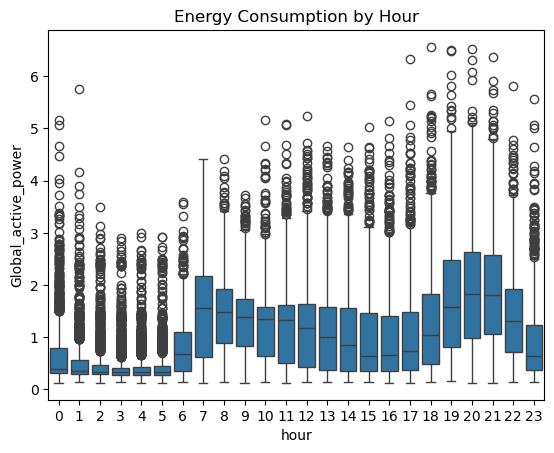

In [50]:
#Energy Usage by Hour
df_features = df_hourly.to_frame()
df_features['hour'] = df_features.index.hour
sns.boxplot(x='hour', y='Global_active_power', data=df_features)
plt.title("Energy Consumption by Hour")
plt.show()

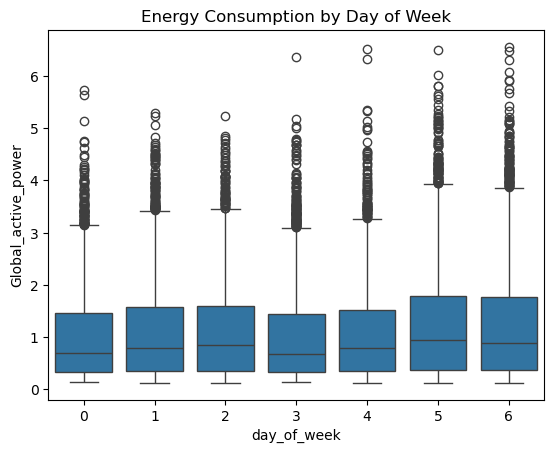

In [51]:
#Energy Usage by week
df_features['day_of_week'] = df_features.index.dayofweek
sns.boxplot(x='day_of_week', y='Global_active_power', data=df_features)
plt.title("Energy Consumption by Day of Week")
plt.show()

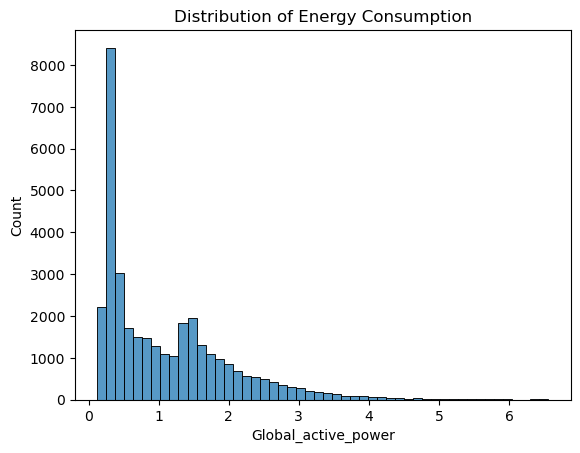

In [52]:
#This shows how energy usage values are distributed.
sns.histplot(df_hourly, bins=50)
plt.title("Distribution of Energy Consumption")
plt.show()

# 5 Model building and evaluation

In [9]:
#Split into train and test
train, test = df_features[:-24], df_features[-24:]

# ARIMA Model

In [10]:
# 1. ARIMA Implementation
arima_model = ARIMA(train['Global_active_power'], order=(5,1,0)).fit()
arima_pred = arima_model.forecast(steps=24)

# Prophet Model

In [11]:
# 2. Prophet Implementation
prophet_df = train.reset_index()[['datetime', 'Global_active_power']].rename(columns={'datetime':'ds', 'Global_active_power':'y'})
m = Prophet().fit(prophet_df)
future = m.make_future_dataframe(periods=24, freq='h')
prophet_pred = m.predict(future)['yhat'][-24:]

14:59:09 - cmdstanpy - INFO - Chain [1] start processing
14:59:24 - cmdstanpy - INFO - Chain [1] done processing


# XGBoost Model

In [12]:
X_train, y_train = train.drop('Global_active_power', axis=1), train['Global_active_power']
X_test = test.drop('Global_active_power', axis=1)
xgb_model = XGBRegressor().fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)

# 6 Plot actual vs. forecasted energy usage for visualization

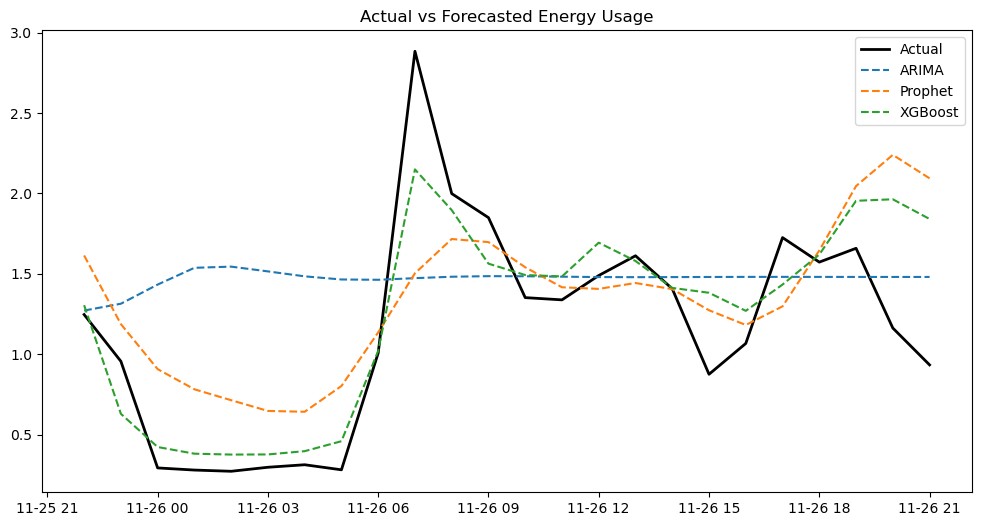

ARIMA MAE: 0.552
Prophet MAE: 0.394
XGBoost MAE: 0.241


In [15]:
plt.figure(figsize=(12, 6))
plt.plot(test.index, test['Global_active_power'], label='Actual', color='black', lw=2)
plt.plot(test.index, arima_pred, label='ARIMA', linestyle='--')
plt.plot(test.index, prophet_pred, label='Prophet', linestyle='--')
plt.plot(test.index, xgb_pred, label='XGBoost', linestyle='--')
plt.title("Actual vs Forecasted Energy Usage")
plt.legend()
plt.show()
print(f"ARIMA MAE: {mae(test['Global_active_power'], arima_pred):.3f}")
print(f"Prophet MAE: {mae(test['Global_active_power'], prophet_pred):.3f}")
print(f"XGBoost MAE: {mae(test['Global_active_power'], xgb_pred):.3f}")

# 7 Final conclusion with insights

In [53]:
#The process of analysis was carried out using the Household Power Consumption Dataset, which is used to predict short-term household power consumption.
#Data cleaning and preprocessing were done using pandas, while time-based feature engineering was done to predict power consumption per hour or per day. 
#Exploratory data analysis showed differences in power consumption depending on different times of the day or different days of the week. 
#Various models, such as ARIMA, Prophet, and XGBoost, were used to carry out the predictions.
#Evaluation of these models was done using MAE and RMSE to determine their precision. Overall, time series models can effectively predict power consumption, thus helping to manage power effectively.